In [1]:
#Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from scipy.stats import zscore
 
## This statement allows the visuals to render within your Jupyter Notebook.
%matplotlib inline

## Loading the data
We can now load the dataset into pandas using the read_csv() function. This converts the CSV file into a Pandas dataframe.

In [2]:
#Read in the csv file and convert to a Pandas dataframe
y2015= pd.read_csv("2015.csv") 
y2016= pd.read_csv("2016.csv") 
y2017= pd.read_csv("2017.csv")
y2018= pd.read_csv("2018.csv")
y2019= pd.read_csv("2019.csv")



### Viewing the dataframe
We can get a quick sense of the size of our dataset by using the shape method. This returns a tuple with the number of rows and columns in the dataset.

In [3]:
y2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
y2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [5]:
y2017.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [6]:
y2018.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357


In [7]:
y2019.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [8]:
y2015.shape , y2016.shape, y2017.shape, y2018.shape, y2019.shape

((158, 12), (157, 13), (155, 12), (156, 9), (156, 9))

In [9]:
# the six factors contributing to happiness is present in the 5 data sets, some have different naming
# rows in all data sets are around the same amount
# year are not present in all data sets, so if we want concat we must add column for the year as we need this to solve the use case

In [10]:
y2015["Year"]= 2015

In [11]:
y2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [12]:
y2016["Year"]= 2016

In [13]:
y2016.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939,2016
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463,2016
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137,2016
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465,2016
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596,2016


In [14]:
y2017["Year"]= 2017

In [15]:
y2017.head()

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual,Year
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,2017
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,2017
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,2017
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,2017
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,2017


In [16]:
y2018["Year"]= 2018

In [17]:
y2018.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393,2018
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340,2018
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408,2018
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138,2018
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357,2018


In [18]:
y2019["Year"]= 2019

In [19]:
y2019.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393,2019
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410,2019
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341,2019
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118,2019
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298,2019


In [20]:
# as you can see same columns have different names
y2015.columns.sort, y2016.columns.sort, y2017.columns.sort,y2018.columns.sort ,y2019.columns.sort

(<bound method Index.sort of Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
        'Standard Error', 'Economy (GDP per Capita)', 'Family',
        'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
        'Generosity', 'Dystopia Residual', 'Year'],
       dtype='object')>,
 <bound method Index.sort of Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
        'Lower Confidence Interval', 'Upper Confidence Interval',
        'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
        'Freedom', 'Trust (Government Corruption)', 'Generosity',
        'Dystopia Residual', 'Year'],
       dtype='object')>,
 <bound method Index.sort of Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
        'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
        'Health..Life.Expectancy.', 'Freedom', 'Generosity',
        'Trust..Government.Corruption.', 'Dystopia.Residual', 'Year'],
       dtype='object')>,
 <bo

In [21]:
# unify colummmns names as a part of consistency
y2015.rename(columns={ "Happiness Rank":"Happiness_rank","Happiness Score": "Happiness_score","Economy (GDP per Capita)": "Economy_GDP","Health (Life Expectancy)": "health_life_expectency","Trust (Government Corruption)":"Trust_in_government","Dystopia Residual": "Dystopia_Residual", "Family":"Family_SocialSupport" }, inplace=True)
y2016.rename(columns={ "Happiness Rank":"Happiness_rank", "Happiness Score": "Happiness_score", "Economy (GDP per Capita)": "Economy_GDP", "Health (Life Expectancy)": "health_life_expectency", "Trust (Government Corruption)":"Trust_in_government", "Dystopia Residual": "Dystopia_Residual" , "Family":"Family_SocialSupport"}, inplace=True)
y2017.rename(columns={ "Happiness.Rank":"Happiness_rank", "Happiness.Score": "Happiness_score", "Economy..GDP.per.Capita.": "Economy_GDP", "Health..Life.Expectancy.": "health_life_expectency", "Trust..Government.Corruption.":"Trust_in_government", "Dystopia.Residual": "Dystopia_Residual" ,"Family":"Family_SocialSupport"}, inplace=True)
y2018.rename(columns={ "Country or region":"Country" , "Overall rank":"Happiness_rank", "Score" : "Happiness_score", "GDP per capita": "Economy_GDP", "Freedom to make life choices":"Freedom", "Healthy life expectancy": "health_life_expectency", "Perceptions of corruption":"Trust_in_government","Social support":"Family_SocialSupport"  }, inplace=True)
y2019.rename(columns={ "Country or region":"Country" , "Overall rank":"Happiness_rank", "Score" : "Happiness_score", "GDP per capita": "Economy_GDP", "Freedom to make life choices":"Freedom", "Healthy life expectancy": "health_life_expectency", "Perceptions of corruption":"Trust_in_government","Social support" :"Family_SocialSupport"  }, inplace=True)

In [22]:
#check columns names
y2015.columns.sort, y2016.columns.sort, y2017.columns.sort,y2018.columns.sort ,y2019.columns.sort

(<bound method Index.sort of Index(['Country', 'Region', 'Happiness_rank', 'Happiness_score',
        'Standard Error', 'Economy_GDP', 'Family_SocialSupport',
        'health_life_expectency', 'Freedom', 'Trust_in_government',
        'Generosity', 'Dystopia_Residual', 'Year'],
       dtype='object')>,
 <bound method Index.sort of Index(['Country', 'Region', 'Happiness_rank', 'Happiness_score',
        'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy_GDP',
        'Family_SocialSupport', 'health_life_expectency', 'Freedom',
        'Trust_in_government', 'Generosity', 'Dystopia_Residual', 'Year'],
       dtype='object')>,
 <bound method Index.sort of Index(['Country', 'Happiness_rank', 'Happiness_score', 'Whisker.high',
        'Whisker.low', 'Economy_GDP', 'Family_SocialSupport',
        'health_life_expectency', 'Freedom', 'Generosity',
        'Trust_in_government', 'Dystopia_Residual', 'Year'],
       dtype='object')>,
 <bound method Index.sort of Index(['Happines

In [23]:
y2018.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Happiness_rank          156 non-null    int64  
 1   Country                 156 non-null    object 
 2   Happiness_score         156 non-null    float64
 3   Economy_GDP             156 non-null    float64
 4   Family_SocialSupport    156 non-null    float64
 5   health_life_expectency  156 non-null    float64
 6   Freedom                 156 non-null    float64
 7   Generosity              156 non-null    float64
 8   Trust_in_government     155 non-null    float64
 9   Year                    156 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 12.3+ KB


In [24]:
#Now we will concat data sets in one data frame and ignore the index
df_Happiness= pd.concat([y2015,y2016,y2017,y2018,y2019], ignore_index=True)
df_Happiness.sample(50)

,Country,Region,Happiness_rank,Happiness_score,Standard Error,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Dystopia_Residual,Year,Lower Confidence Interval,Upper Confidence Interval,Whisker.high,Whisker.low
331,Belgium,NaN,17,6.891,NaN,1.463781,1.462313,0.818092,0.539771,0.251343,0.231503,2.124210,2017,NaN,NaN,6.955821,6.826179
21,Oman,Middle East and Northern Africa,22,6.853,0.05335,1.360110,1.081820,0.762760,0.632740,0.325240,0.215420,2.474890,2015,NaN,NaN,NaN,NaN
371,Romania,NaN,57,5.825,NaN,1.217684,1.150091,0.685158,0.457004,0.004388,0.133520,2.176831,2017,NaN,NaN,5.919694,5.730305
643,Belgium,NaN,18,6.923,NaN,1.356000,1.504000,0.986000,0.473000,0.210000,0.160000,NaN,2019,NaN,NaN,NaN,NaN
180,United Kingdom,Western Europe,23,6.725,NaN,1.402830,1.086720,0.809910,0.500360,0.273990,0.501560,2.149990,2016,6.647,6.803,NaN,NaN
230,Jamaica,Latin America and Caribbean,73,5.510,NaN,0.893330,0.963720,0.594690,0.435970,0.042940,0.222450,2.356820,2016,5.315,5.705,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.459000,1.330950,0.885210,0.669730,0.365030,0.346990,2.465310,2015,NaN,NaN,NaN,NaN
25,Germany,Western Europe,26,6.750,0.01848,1.327920,1.299370,0.891860,0.614770,0.218430,0.282140,2.115690,2015,NaN,NaN,NaN,NaN
596,Ethiopia,NaN,127,4.350,NaN,0.308000,0.950000,0.391000,0.452000,0.146000,0.220000,NaN,2018,NaN,NaN,NaN,NaN
105,Tajikistan,Central and Eastern Europe,106,4.786,0.03198,0.390470,0.855630,0.573790,0.472160,0.150720,0.229740,2.113990,2015,NaN,NaN,NaN,NaN


## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data. 

In [25]:
df_Happiness.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    782 non-null    object 
 1   Region                     315 non-null    object 
 2   Happiness_rank             782 non-null    int64  
 3   Happiness_score            782 non-null    float64
 4   Standard Error             158 non-null    float64
 5   Economy_GDP                782 non-null    float64
 6   Family_SocialSupport       782 non-null    float64
 7   health_life_expectency     782 non-null    float64
 8   Freedom                    782 non-null    float64
 9   Trust_in_government        781 non-null    float64
 10  Generosity                 782 non-null    float64
 11  Dystopia_Residual          470 non-null    float64
 12  Year                       782 non-null    int64  
 13  Lower Confidence Interval  157 non-null    float64

In [26]:
#as the six factors is important for the analysis I want to make sure which year the null value in Trust_in_government 
slack= df_Happiness[df_Happiness["Trust_in_government"].isnull()]
group_by_year= slack.groupby('Year')
group_by_year.size()

Year
2018    1
dtype: int64

In [27]:
df_Happiness.shape

(782, 17)

In [28]:
df_Happiness.describe()

,Happiness_rank,Happiness_score,Standard Error,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Dystopia_Residual,Year,Lower Confidence Interval,Upper Confidence Interval,Whisker.high,Whisker.low
count,782.000000,782.000000,158.000000,782.000000,782.000000,782.000000,782.000000,781.000000,782.000000,470.000000,782.000000,157.000000,157.000000,155.000000,155.000000
mean,78.698210,5.379018,0.047885,0.916047,1.078392,0.612416,0.411091,0.125436,0.218576,2.092717,2016.993606,5.282395,5.481975,5.452326,5.255713
std,45.182384,1.127456,0.017146,0.407340,0.329548,0.248309,0.152880,0.105816,0.122321,0.565772,1.417364,1.148043,1.136493,1.118542,1.145030
min,1.000000,2.693000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580,2015.000000,2.732000,3.078000,2.864884,2.521116
25%,40.000000,4.509750,0.037268,0.606500,0.869363,0.440183,0.309768,0.054000,0.130000,1.737975,2016.000000,4.327000,4.465000,4.608172,4.374955
50%,79.000000,5.322000,0.043940,0.982205,1.124735,0.647310,0.431000,0.091000,0.201982,2.094640,2017.000000,5.237000,5.419000,5.370032,5.193152
75%,118.000000,6.189500,0.052300,1.236187,1.327250,0.808000,0.531000,0.156030,0.278832,2.455575,2018.000000,6.154000,6.434000,6.194600,6.006527
max,158.000000,7.769000,0.136930,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075,3.837720,2019.000000,7.460000,7.669000,7.622030,7.479556


The process of profiling differs slightly for categorical and numerical variables due to their inherent differences.

**The two main types of data are:**
- Quantitative (numerical) data
- Qualitative (categorical) data

### Data Quality Checks
Data quality checks involve the process of ensuring that the data is accurate, complete, consistent, relevant, and reliable. 


**Here are typical steps involved in checking data quality:**

#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.

In [29]:
# data from the Gallup World Poll
#The Gallup World Poll covers more than 160 countries, representing over 98% of the world's population. 
#It uses scientific sampling methods to ensure that the survey data is representative of the national population. So its trustworthy to analyze

#### 2. Timeliness: 
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.

In [30]:
#its acceptable for analysis

#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [31]:
#as I concat different data soureces in one data frame I modified columns names to be consistent 
df_Happiness.info()
#You can see every column have specific type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    782 non-null    object 
 1   Region                     315 non-null    object 
 2   Happiness_rank             782 non-null    int64  
 3   Happiness_score            782 non-null    float64
 4   Standard Error             158 non-null    float64
 5   Economy_GDP                782 non-null    float64
 6   Family_SocialSupport       782 non-null    float64
 7   health_life_expectency     782 non-null    float64
 8   Freedom                    782 non-null    float64
 9   Trust_in_government        781 non-null    float64
 10  Generosity                 782 non-null    float64
 11  Dystopia_Residual          470 non-null    float64
 12  Year                       782 non-null    int64  
 13  Lower Confidence Interval  157 non-null    float64

#### 4. Relevance: 
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [32]:
df_Happiness.head(10)

,Country,Region,Happiness_rank,Happiness_score,Standard Error,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Dystopia_Residual,Year,Lower Confidence Interval,Upper Confidence Interval,Whisker.high,Whisker.low
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN
5,Finland,Western Europe,6,7.406,0.03140,1.29025,1.31826,0.88911,0.64169,0.41372,0.23351,2.61955,2015,NaN,NaN,NaN,NaN
6,Netherlands,Western Europe,7,7.378,0.02799,1.32944,1.28017,0.89284,0.61576,0.31814,0.47610,2.46570,2015,NaN,NaN,NaN,NaN
7,Sweden,Western Europe,8,7.364,0.03157,1.33171,1.28907,0.91087,0.65980,0.43844,0.36262,2.37119,2015,NaN,NaN,NaN,NaN
8,New Zealand,Australia and New Zealand,9,7.286,0.03371,1.25018,1.31967,0.90837,0.63938,0.42922,0.47501,2.26425,2015,NaN,NaN,NaN,NaN
9,Australia,Australia and New Zealand,10,7.284,0.04083,1.33358,1.30923,0.93156,0.65124,0.35637,0.43562,2.26646,2015,NaN,NaN,NaN,NaN


In [33]:
df_Happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    782 non-null    object 
 1   Region                     315 non-null    object 
 2   Happiness_rank             782 non-null    int64  
 3   Happiness_score            782 non-null    float64
 4   Standard Error             158 non-null    float64
 5   Economy_GDP                782 non-null    float64
 6   Family_SocialSupport       782 non-null    float64
 7   health_life_expectency     782 non-null    float64
 8   Freedom                    782 non-null    float64
 9   Trust_in_government        781 non-null    float64
 10  Generosity                 782 non-null    float64
 11  Dystopia_Residual          470 non-null    float64
 12  Year                       782 non-null    int64  
 13  Lower Confidence Interval  157 non-null    float64

In [34]:

slack= df_Happiness[df_Happiness["Standard Error"].isnull()]
group_by_year= slack.groupby('Year')
group_by_year.size()
#after running the above code missing values are in all years except 2015 
# as the usecase is not focusing on the result of this column and its not one of the sex factor . will drop this column in data cleaning

Year
2016    157
2017    155
2018    156
2019    156
dtype: int64

In [36]:
df_Happiness.columns

Index(['Country', 'Region', 'Happiness_rank', 'Happiness_score', 'Economy_GDP',
       'Family_SocialSupport', 'health_life_expectency', 'Freedom',
       'Trust_in_government', 'Generosity', 'Dystopia_Residual', 'Year',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Whisker.high', 'Whisker.low'],
      dtype='object')

#### 5. Uniqueness: 
Check for and remove duplicate records to prevent skewed analysis results.


In [37]:
df_Happiness.duplicated().sum()


0

In [39]:
# go to delete duplicates columns

#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [38]:
#Display number missing values per column
df_Happiness.isnull().sum().sort_values(ascending = False)

#this result after i drop columns: Dystopia_Residual, Lower Confidence Interval, Upper Confidence Interval, Whisker.high, Whisker.low

Whisker.high                 627
Whisker.low                  627
Lower Confidence Interval    625
Upper Confidence Interval    625
Region                       467
Dystopia_Residual            312
Trust_in_government            1
Country                        0
Happiness_rank                 0
Happiness_score                0
Economy_GDP                    0
Family_SocialSupport           0
health_life_expectency         0
Freedom                        0
Generosity                     0
Year                           0
dtype: int64

In [39]:

slack= df_Happiness[df_Happiness["Whisker.high"].isnull()]
group_by_year= slack.groupby('Year')
group_by_year.size()
# this code shows that Whisker.high column have  null in all years except in 2015 because this column exist just in 2015 data set.
#we will drop columns with nulls after checking that it will not effect our analysis, and these columns are not one of the six factors 
#go to data cleaning


Year
2015    158
2016    157
2018    156
2019    156
dtype: int64

In [42]:
df_Happiness.isnull().sum().sort_values(ascending = False)
#region have 467 missing value 

Region                    467
Trust_in_government         1
Country                     0
Happiness_rank              0
Happiness_score             0
Economy_GDP                 0
Family_SocialSupport        0
health_life_expectency      0
Freedom                     0
Generosity                  0
Year                        0
dtype: int64

In [43]:
#Region just exists in 2015 and 2016 the rest of datasets doesn't have this column 
slack2= df_Happiness[df_Happiness["Region"].isnull()]
group_by_year= slack2.groupby('Year')
group_by_year.size()
## maps each country to its region based on the 2015 and 2016 data 
# and use that to fill in the missing values for other years.


Year
2017    155
2018    156
2019    156
dtype: int64

In [48]:
df_Happiness.isnull().sum()

Country                   0
Region                    0
Happiness_rank            0
Happiness_score           0
Economy_GDP               0
Family_SocialSupport      0
health_life_expectency    0
Freedom                   0
Trust_in_government       1
Generosity                0
Year                      0
dtype: int64

In [49]:
df_Happiness[df_Happiness['Trust_in_government'].isnull()]
#The UAE does not declare their trust in government score, replace it with 
# average of Trust_in_government in 2019 and 2017 and put the result in null value in 2018, go data cleaning

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
489,United Arab Emirates,Middle East and Northern Africa,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186,2018


In [55]:
df_Happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 782 non-null    object 
 1   Region                  782 non-null    object 
 2   Happiness_rank          782 non-null    int64  
 3   Happiness_score         782 non-null    float64
 4   Economy_GDP             782 non-null    float64
 5   Family_SocialSupport    782 non-null    float64
 6   health_life_expectency  782 non-null    float64
 7   Freedom                 782 non-null    float64
 8   Trust_in_government     782 non-null    float64
 9   Generosity              782 non-null    float64
 10  Year                    782 non-null    int64  
dtypes: float64(7), int64(2), object(2)
memory usage: 67.3+ KB


#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [56]:
# check columns types 
df_Happiness.dtypes
#data types are correct

Country                    object
Region                     object
Happiness_rank              int64
Happiness_score           float64
Economy_GDP               float64
Family_SocialSupport      float64
health_life_expectency    float64
Freedom                   float64
Trust_in_government       float64
Generosity                float64
Year                        int64
dtype: object

In [57]:
#as it appears the data types of columns is appropriate but will round floats to two
df_Happiness.head(10)

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.253245,0.29678,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.253245,0.43630,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.253245,0.34139,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.253245,0.34699,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.253245,0.45811,2015
5,Finland,Western Europe,6,7.406,1.29025,1.31826,0.88911,0.64169,0.253245,0.23351,2015
6,Netherlands,Western Europe,7,7.378,1.32944,1.28017,0.89284,0.61576,0.253245,0.47610,2015
7,Sweden,Western Europe,8,7.364,1.33171,1.28907,0.91087,0.65980,0.253245,0.36262,2015
8,New Zealand,Australia and New Zealand,9,7.286,1.25018,1.31967,0.90837,0.63938,0.253245,0.47501,2015
9,Australia,Australia and New Zealand,10,7.284,1.33358,1.30923,0.93156,0.65124,0.253245,0.43562,2015


In [58]:
df_Happiness['Economy_GDP']= df_Happiness['Economy_GDP'].apply(lambda x: round(x,2))
df_Happiness['Family_SocialSupport']= df_Happiness['Family_SocialSupport'].apply(lambda x: round(x,2))
df_Happiness['health_life_expectency']= df_Happiness['health_life_expectency'].apply(lambda x: round(x,2))
df_Happiness['Freedom']= df_Happiness['Freedom'].apply(lambda x: round(x,2))
df_Happiness['Trust_in_government']= df_Happiness['Trust_in_government'].apply(lambda x: round(x,2))
df_Happiness['Generosity']= df_Happiness['Generosity'].apply(lambda x: round(x,2))

In [59]:
df_Happiness.head(2)

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
0,Switzerland,Western Europe,1,7.587,1.4,1.35,0.94,0.67,0.25,0.30,2015
1,Iceland,Western Europe,2,7.561,1.3,1.40,0.95,0.63,0.25,0.44,2015


check outliers

In [60]:
# go to clean them 
df_Happiness.head(2)

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
0,Switzerland,Western Europe,1,7.587,1.4,1.35,0.94,0.67,0.25,0.30,2015
1,Iceland,Western Europe,2,7.561,1.3,1.40,0.95,0.63,0.25,0.44,2015


In [52]:
# check outliers 

**What is an Outlier?** 
Outlier is an row/observation that appears far away and diverges from an overall pattern in a sample.

**What are the types of Outliers?**
1. Univariate: These outliers can be found when we look at distribution of a single variable
2. Multivariate: are outliers in an n-dimensional space. In order to find them, you have to look at distributions in multi-dimensions. example (hight=100, weight=100) for a person

**What causes Outliers?**
Whenever we come across outliers, the ideal way to tackle them is to find out the reason of having these outliers. The method to deal with them would then depend on the reason of their occurrence.

Let’s understand various types of outliers:

1. Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
2. Measurement Error: It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.
3. Data Processing Error: Whenever we perform data mining, we extract data from multiple sources. It is possible that some manipulation or extraction errors may lead to outliers in the dataset.
4. Sampling error: For instance, we have to measure the height of athletes. By mistake, we include a few basketball players in the sample. This inclusion is likely to cause outliers in the dataset.
5. Natural Outlier: When an outlier is not artificial (due to error), it is a natural outlier. For instance: In my last assignment with one of the renowned insurance company, I noticed that the performance of top 50 financial advisors was far higher than rest of the population. Surprisingly, it was not due to any error. Hence, whenever we perform any data mining activity with advisors, we used to treat this segment separately.


**What is the impact of Outliers on a dataset?**


![image.png](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/Outlier_31.png)



**How to detect Outliers?**

1. Most commonly used method to detect outliers is visualization (Univariate Graphical Analysis).

We use 3 common visualization methods:
>- Box-plot: A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of the box to show the range of the data. Outlier points are those past the end of the whiskers. Box plots show robust measures of location and spread as well as providing information about symmetry and outliers.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:698/format:webp/1*VK5iHA2AB28HSZwWwUbNYg.png)
>
>
>- Histogram
>- Scatter Plot: A scatter plot is a mathematical diagram using Cartesian coordinates to display values for two variables for a set of data. The data are displayed as a collection of points, each having the value of one variable determining the position on the horizontal axis and the value of the other variable determining the position on the vertical axis. The points that are far from the population can be termed as an outlier.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*Ov6aH-8yIwNoUxtMFwgx4g.png)
>
>

2. Using statistical method (Univariate Non-Graphical analysis):
>- Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR
 
![image.png](https://www.whatissixsigma.net/wp-content/uploads/2015/07/Box-Plot-Diagram-to-identify-Outliers-figure-1.png)

>- Use capping methods. Any value which out of range of 5th and 95th percentile can be considered as outlier
>- Data points, three or more standard deviation away from mean are considered outlier: The Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. While calculating the Z-score we re-scale and center the data and look for data points that are too far from zero. These data points which are way too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.
> - Outlier detection is merely a special case of the examination of data for influential data points and it also depends on the business understanding


In [53]:
# go to univariate graphical analysis
# go to lesson : data visualisation 1 - chart type section
# then go to univariate graphical analysis
# detect outliers using graphs varbaly

In [54]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 

In [61]:
# Calculate (5th percentile) and (95th percentile)
v_5 = df_Happiness['Generosity'].quantile(0.05)
v_95 = df_Happiness['Generosity'].quantile(0.95)
print(v_5, v_95)

# Filter out outliers
df_Happiness[(df_Happiness['Generosity'] < v_5) | (df_Happiness['Generosity'] > v_95)].shape

0.05 0.47


(65, 11)

In [56]:
# go to delete ouliers

## 2. Data Cleaning: 

Preliminary findings from data profiling can lead to cleaning the data by:
- Handling missing values
- Correcting errors.
- Dealing with outliers.

-------------------



### Handling missing values:

**Why my data has missing values?**
They may occur at two stages:
1. Data Extraction: It is possible that there are problems with extraction process. Errors at data extraction stage are typically easy to find and can be corrected easily as well.
2. Data collection: These errors occur at time of data collection and are harder to correct.

**Why do we need to handle the missing data?**
To avoid:
- Bias the conclusions.
- Leading the business to make wrong decisions.

**Which are the methods to treat missing values ?**
1. Deletion: we delete rows where any of the variable is missing. Simplicity is one of the major advantage of this method, but this method reduces the power of model because it reduces the sample size.

2. Imputation: is a method to fill in the missing values with estimated ones. This imputation is one of the most frequently used methods.

    2.1. Mean/ Mode/ Median Imputation: It consists of replacing the missing data for a given attribute by the mean or median (quantitative attribute) or mode (qualitative attribute) of all known values of that variable.
    > It can be of two types:
    > - Generalized Imputation: In this case, we calculate the mean or median for all non missing values of that variable then replace missing value with mean or median.
    > - Similar case Imputation: In this case, we calculate average for each group individually of non missing values then replace the missing value based on the group.

    2.2. Constant Value
   
    2.3. Forward Filling
   
    2.4. Backward Filling

6. Prediction Model:  Prediction model is one of the sophisticated method for handling missing data. Here, we create a predictive model to estimate values that will substitute the missing data.  In this case, we divide our data set into two sets: One set with no missing values for the variable and another one with missing values. First data set become training data set of the model while second data set with missing values is test data set and variable with missing values is treated as target variable. Next, we create a model to predict target variable based on other attributes of the training data set and populate missing values of test data set.

> There are 2 drawbacks for this approach:
> - The model estimated values are usually more well-behaved than the true values
> - If there are no relationships with attributes in the data set and the attribute with missing values, then the model will not be precise for estimating missing values.

9. KNN Imputation: In this method of imputation, the missing values of an attribute are imputed using the given number of attributes that are most similar to the attribute whose values are missing. The similarity of two attributes is determined using a distance function. It is also known to have certain advantage & disadvantages.

   > **Advantages:**
   > - k-nearest neighbour can predict both qualitative & quantitative attributes
   > - Creation of predictive model for each attribute with missing data is not required
   > - Attributes with multiple missing values can be easily treated
   > - Correlation structure of the data is taken into consideration

   > **Disadvantage:**
   > - KNN algorithm is very time-consuming in analyzing large database. It searches through all the dataset looking for the most similar instances.
   > - Choice of k-value is very critical. Higher value of k would include attributes which are significantly different from what we need whereas lower value of k implies missing out of significant attributes.

--------------------


In [35]:
df_Happiness.drop(["Standard Error"], axis=1,inplace=True)

In [58]:
# go back to 6th dimention --> Completeness

In [40]:
df_Happiness.drop(["Dystopia_Residual","Lower Confidence Interval", "Upper Confidence Interval", "Whisker.high", "Whisker.low"], axis=1, inplace=True)

In [41]:
df_Happiness.head()

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
0,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


In [44]:
# maps each country to its region based on the 2015 and 2016 data and use that to fill in the missing values for other years.
region_map = df_Happiness[df_Happiness['Year'].isin([2015, 2016])].set_index('Country')['Region'].to_dict()


df_Happiness['Region'] = df_Happiness['Country'].map(region_map)

In [45]:
df_Happiness.isnull().sum()

Country                   0
Region                    8
Happiness_rank            0
Happiness_score           0
Economy_GDP               0
Family_SocialSupport      0
health_life_expectency    0
Freedom                   0
Trust_in_government       1
Generosity                0
Year                      0
dtype: int64

In [46]:
df_Happiness['Region']=df_Happiness['Region'].fillna("unknown")

In [47]:
df_Happiness['Region'].isnull().sum()

0

In [50]:
df_Happiness[df_Happiness['Trust_in_government'].isnull()]

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
489,United Arab Emirates,Middle East and Northern Africa,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186,2018


In [51]:
df_Happiness[(df_Happiness['Country']=="United Arab Emirates" ) ]

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
19,United Arab Emirates,Middle East and Northern Africa,20,6.901,1.427270,1.12575,0.809250,0.641570,0.38583,0.264280,2015
185,United Arab Emirates,Middle East and Northern Africa,28,6.573,1.573520,0.87114,0.729930,0.562150,0.35561,0.265910,2016
335,United Arab Emirates,Middle East and Northern Africa,21,6.648,1.626343,1.26641,0.726798,0.608345,0.32449,0.360942,2017
489,United Arab Emirates,Middle East and Northern Africa,20,6.774,2.096000,0.77600,0.670000,0.284000,NaN,0.186000,2018
646,United Arab Emirates,Middle East and Northern Africa,21,6.825,1.503000,1.31000,0.825000,0.598000,0.18200,0.262000,2019


In [52]:
#take the average of trust in government in 2017 and 2019 into 2018
bef_year=df_Happiness['Trust_in_government'].iloc[335]
after_year=df_Happiness['Trust_in_government'].iloc[646]
df_Happiness['Trust_in_government']=df_Happiness['Trust_in_government'].iloc[489]=(bef_year+after_year)/2

/var/folders/9h/pxzr449s043f60c5wxm59_l80000gn/T/ipykernel_28599/798436929.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_Happiness['Trust_in_government']=df_Happiness['Trust_in_government'].iloc[489]=(bef_year+after_year)/2
/var/fol

In [53]:
df_Happiness[(df_Happiness['Country']=="United Arab Emirates" ) ]

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
19,United Arab Emirates,Middle East and Northern Africa,20,6.901,1.427270,1.12575,0.809250,0.641570,0.253245,0.264280,2015
185,United Arab Emirates,Middle East and Northern Africa,28,6.573,1.573520,0.87114,0.729930,0.562150,0.253245,0.265910,2016
335,United Arab Emirates,Middle East and Northern Africa,21,6.648,1.626343,1.26641,0.726798,0.608345,0.253245,0.360942,2017
489,United Arab Emirates,Middle East and Northern Africa,20,6.774,2.096000,0.77600,0.670000,0.284000,0.253245,0.186000,2018
646,United Arab Emirates,Middle East and Northern Africa,21,6.825,1.503000,1.31000,0.825000,0.598000,0.253245,0.262000,2019


In [54]:
df_Happiness.isnull().sum()

Country                   0
Region                    0
Happiness_rank            0
Happiness_score           0
Economy_GDP               0
Family_SocialSupport      0
health_life_expectency    0
Freedom                   0
Trust_in_government       0
Generosity                0
Year                      0
dtype: int64

### Correcting errors

-------------------

In [70]:
# go back to 7th dimension Accuracy 

### Dealing with outliers:

**How to remove Outliers?**
Most of the ways to deal with outliers are similar to the methods of missing values like deleting rows, transforming them, binning them, treat them as a separate group, imputing values and other statistical methods. Here, we will discuss the common techniques used to deal with outliers:

1. Deleting rows: We delete outlier values if it is due to data entry error, data processing error or outlier rows are very small in numbers. We can also use trimming at both ends to remove outliers.

2. Imputing: Like imputation of missing values, we can also impute outliers. We can use mean, median, mode imputation methods. Before imputing values, we should analyse if it is natural outlier or artificial. If it is artificial, we can go with imputing values. We can also use statistical model to predict values of outlier rows and after that we can impute it with predicted values.

3. Treat separately: If there are significant number of outliers, we should treat them separately in the statistical model. One of the approach is to treat both groups as two different groups and build individual model for both groups and then combine the output.


In [62]:
#as the data is small we will keep it as it will effect the analysis
df_Happiness[(df_Happiness['Generosity'] < v_5) | (df_Happiness['Generosity'] > v_95)].shape

(65, 11)

## 3. Univariate Analysis: 

This involves examining single variables to understand their characteristics (distribution, central tendency, dispersion, and shape).

We calculate **numerical values** about the data that tells us about the distribution of the data. We also **draw graphs** showing visually how the data is distributed. **To answer the following questions about Features/characteristics of Data:**
- Where is the center of the data? (location)
- How much does the data vary? (scale)
- What is the shape of the data? (shape)

**The benefits of this analysis:**
Statistics summary gives a high-level idea to identify whether the data has any outliers, data entry error, distribution of data such as the data is normally distributed or left/right skewed

**In this step, we will explore variables one by one using following approaches:**

### 1. Univariate Graphical Analysis:
Method to perform uni-variate analysis will depend on whether the variable type is categorical or numerical.

In [66]:
df_Happiness.head(2)

,Country,Region,Happiness_rank,Happiness_score,Economy_GDP,Family_SocialSupport,health_life_expectency,Freedom,Trust_in_government,Generosity,Year
0,Switzerland,Western Europe,1,7.587,1.4,1.35,0.94,0.67,0.25,0.30,2015
1,Iceland,Western Europe,2,7.561,1.3,1.40,0.95,0.63,0.25,0.44,2015


#### I. Categorical Variables:

we’ll use frequency table to understand distribution of each category
- Bar Chart (Ordinal) - Orderd
- Pie Chart (Nominal) - non Orderd

In [67]:
df_Happiness.dtypes

Country                    object
Region                     object
Happiness_rank              int64
Happiness_score           float64
Economy_GDP               float64
Family_SocialSupport      float64
health_life_expectency    float64
Freedom                   float64
Trust_in_government       float64
Generosity                float64
Year                        int64
dtype: object

In [68]:
df_Happiness['Region']

0          Western Europe
1          Western Europe
2          Western Europe
3          Western Europe
4           North America
              ...        
777    Sub-Saharan Africa
778    Sub-Saharan Africa
779         Southern Asia
780    Sub-Saharan Africa
781    Sub-Saharan Africa
Name: Region, Length: 782, dtype: object

In [69]:
count_region=df_Happiness['Region'].value_counts().head(10)
count_region.mode


<bound method Series.mode of Region
Sub-Saharan Africa                 195
Central and Eastern Europe         144
Latin America and Caribbean        109
Western Europe                     103
Middle East and Northern Africa     96
Southeastern Asia                   44
Southern Asia                       35
Eastern Asia                        28
North America                       10
Australia and New Zealand           10
Name: count, dtype: int64>

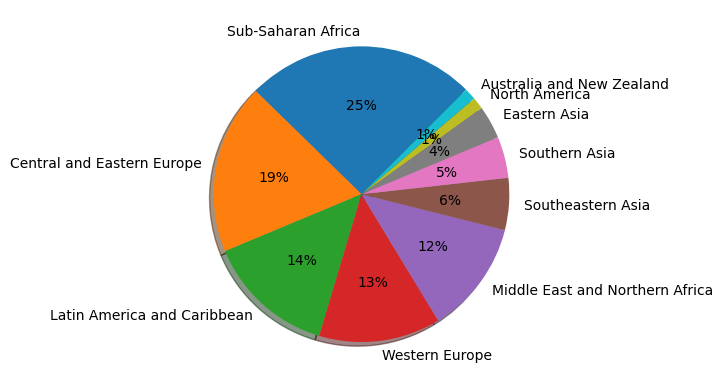

In [70]:
plt.pie(x=count_region.values,
        labels=count_region.index,
        startangle=45,
        shadow=True,
        autopct='%1.0f%%'
       )
plt.show()

#### II. Numerical Variables:

we need to understand the central tendency and spread of the variable (Descriptive Analysis) using:
   - Box plot
   - Histogram

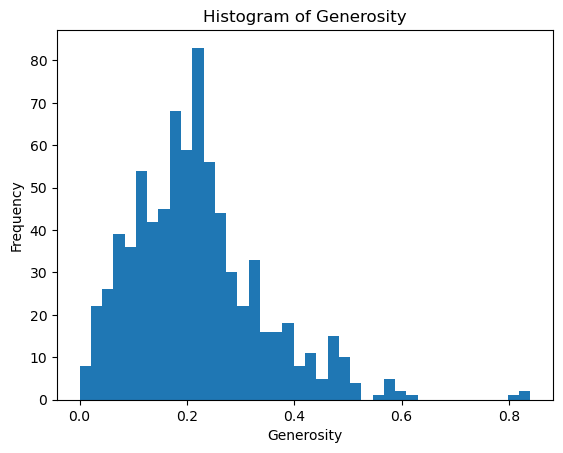

In [71]:
plt.hist(df_Happiness['Generosity'],
         #,facecolor = 'b', edgecolor = 'red',
         bins = 40
        ) # bins = 6 means 6 bars
plt.xlabel('Generosity')
plt.ylabel('Frequency')
plt.title(f'Histogram of Generosity')
plt.show()

### 2. Univariate Non-Graphical analysis: 

- Where is the center of the data? (location) --> **Measures of central tendency**
- How much does the data vary? (scale) --> **Measure of variability**
- What is the shape of the data? (shape) --> **Measures of variation combined with an average (measure of center) gives a good picture of the distribution of the data.**

In [72]:
df_Happiness.describe().T

,count,mean,std,min,25%,50%,75%,max
Happiness_rank,782.0,78.698210,45.182384,1.000,40.00000,79.000,118.0000,158.000
Happiness_score,782.0,5.379018,1.127456,2.693,4.50975,5.322,6.1895,7.769
Economy_GDP,782.0,0.915895,0.407270,0.000,0.60250,0.980,1.2375,2.100
Family_SocialSupport,782.0,1.078286,0.329508,0.000,0.87000,1.120,1.3275,1.640
health_life_expectency,782.0,0.612558,0.248349,0.000,0.44000,0.650,0.8100,1.140
Freedom,782.0,0.411164,0.152750,0.000,0.31000,0.430,0.5300,0.720
Trust_in_government,782.0,0.250000,0.000000,0.250,0.25000,0.250,0.2500,0.250
Generosity,782.0,0.218478,0.122291,0.000,0.13000,0.200,0.2800,0.840
Year,782.0,2016.993606,1.417364,2015.000,2016.00000,2017.000,2018.0000,2019.000


In [73]:
df_Happiness.describe(include='object').T

,count,unique,top,freq
Country,782,170,Switzerland,5
Region,782,11,Sub-Saharan Africa,195


## 4. Bivariate/Multivariate Analysis:

Here, you look at the relationships between two or more variables. This can involve looking for correlations, patterns, and trends that suggest a relationship or an association.

We can perform bi-variate analysis for any combination of categorical and numerical variables. The combination can be:
| bi-variate variables   | Plot type |
| ------------- | ------------- |
| Categorical & Categorical| Stacked Bar Chart |
| Categorical & numerical  | scatter plot, histogram, box plot|
| numerical  & numerical  | Scatter plot, line chart| 


Multivariate Analysis:
- Heat map
- Bar Chart
- Scatter Chart
- Line Chart

**Categorical & Categorical --> (Stacked Column Chart)**

#### Q1  using 2019 data set which is the earliest 

In [74]:
top_25_region_count = (df_Happiness[df_Happiness['Year'] == 2019].nlargest(25, 'Happiness_score')['Region'].value_counts()  
)

<Axes: xlabel='count', ylabel='Region'>

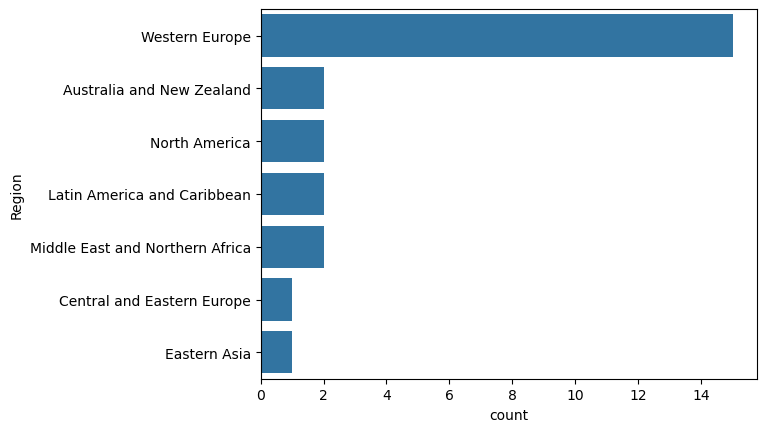

In [75]:
sns.barplot(y="Region", x="count",data=top_25_region_count.to_frame())

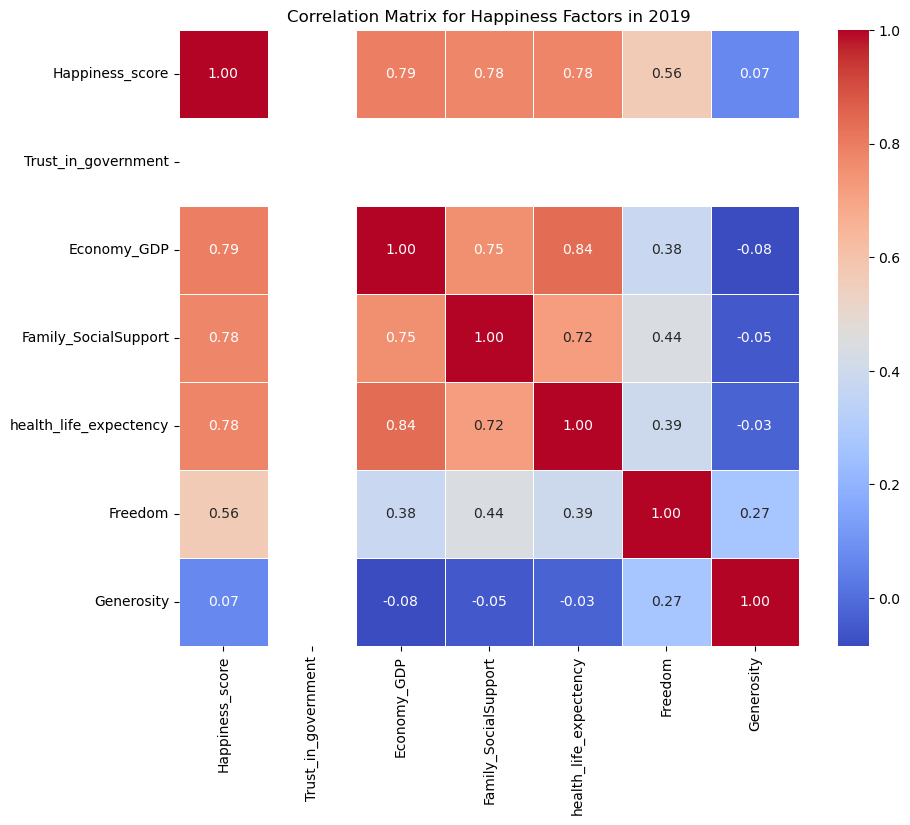

In [96]:
df_2019 = df_Happiness[df_Happiness['Year'] == 2019]

factors = [ 'Happiness_score', 'Trust_in_government','Economy_GDP', 'Family_SocialSupport', 'health_life_expectency', 'Freedom', 'Generosity']

corr_matrix = df_2019[factors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix for Happiness Factors in 2019')

plt.show()

#### Q2 

**Categorical & numerical --> (scatter plot, histogram, box plot)**

In [97]:
df_2015 = df_Happiness[df_Happiness['Year'] == 2015].head(10)
df_2016 = df_Happiness[df_Happiness['Year'] == 2016].head(10)
df_2017 = df_Happiness[df_Happiness['Year'] == 2017].head(10)
df_2018 = df_Happiness[df_Happiness['Year'] == 2018].head(10)

In [122]:
comparison_table = df_2015[['Country', 'Happiness_rank']].merge(
    df_2016[['Country', 'Happiness_rank']],
    on='Country',
    suffixes=('_2015', '_2016')
).set_index('Country')

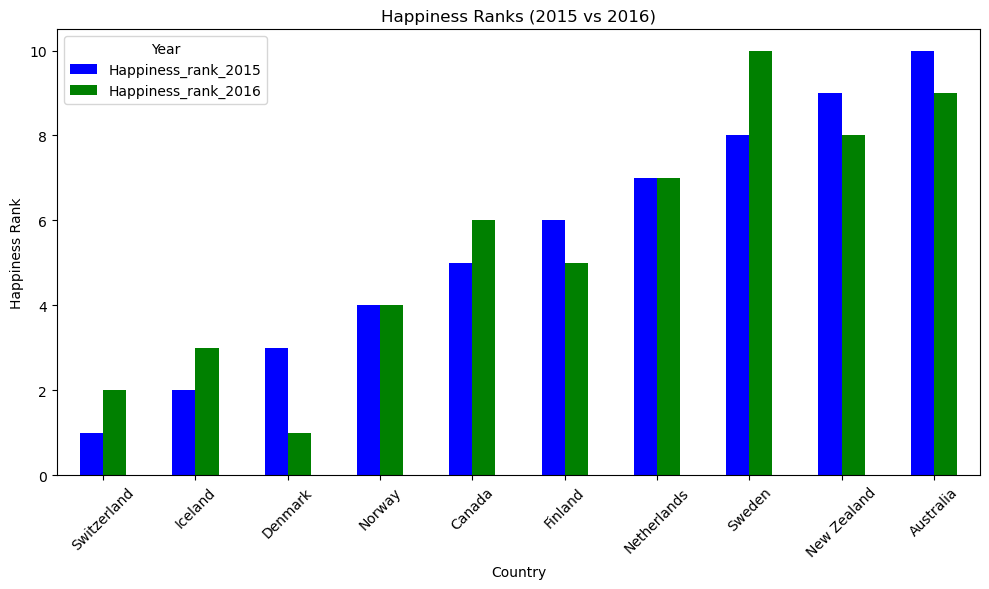

In [123]:
comparison_table.plot(kind='bar', stacked=False, figsize=(10, 6), color=['blue', 'green'])
plt.title('Happiness Ranks (2015 vs 2016)')
plt.ylabel('Happiness Rank')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [124]:
comparison_table2 = df_2016[['Country', 'Happiness_rank']].merge(
    df_2017[['Country', 'Happiness_rank']],
    on='Country',
    suffixes=('_2016', '_2017')
).set_index('Country')

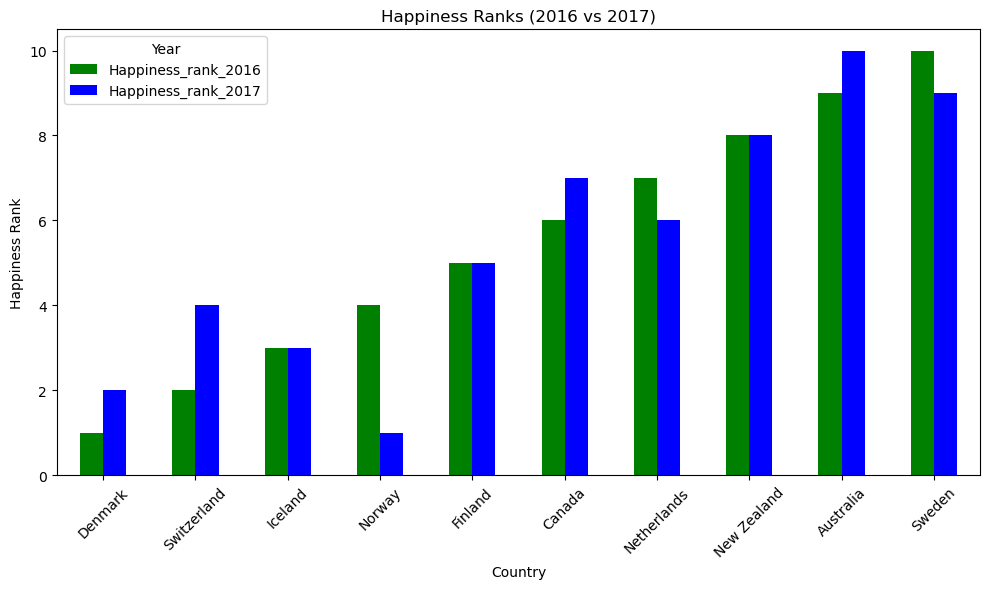

In [125]:
comparison_table2.plot(kind='bar', stacked=False, figsize=(10, 6), color=['green', 'blue'])
plt.title('Happiness Ranks (2016 vs 2017)')
plt.ylabel('Happiness Rank')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

#### Q3

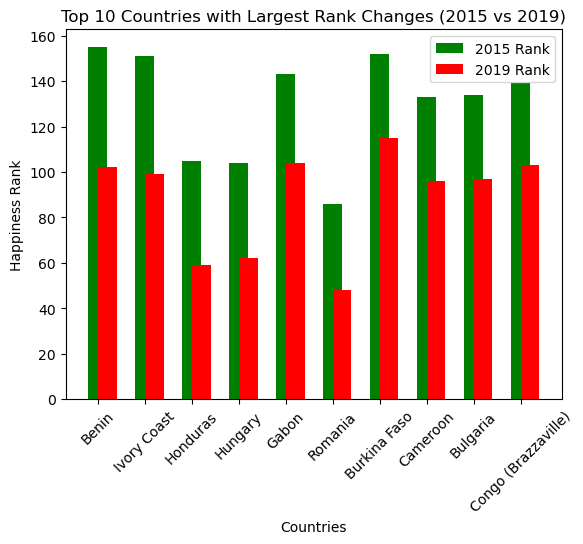

In [167]:
df_2015 = df_Happiness[df_Happiness['Year'] == 2015][['Country', 'Happiness_rank']]
df_2019 = df_Happiness[df_Happiness['Year'] == 2019][['Country', 'Happiness_rank']]

df_comparison = pd.merge(df_2015, df_2019, on='Country', suffixes=('_2015', '_2019'))
df_comparison['Rank_Change'] = df_comparison['Happiness_rank_2015'] - df_comparison['Happiness_rank_2019']


df_comparison_sorted = df_comparison.sort_values('Rank_Change', ascending=False)
#top 10 countries with the largest changes
top_10_changes = df_comparison_sorted.head(10)

x = range(len(top_10_changes))  
plt.bar(x, top_10_changes['Happiness_rank_2015'], width=0.4, label='2015 Rank', color='green', align='center')
plt.bar(x, top_10_changes['Happiness_rank_2019'], width=0.4, label='2019 Rank', color='red', align='edge')

plt.xlabel('Countries')
plt.ylabel('Happiness Rank')
plt.title('Top 10 Countries with Largest Rank Changes (2015 vs 2019)')
plt.xticks(x, top_10_changes['Country'], rotation=45)
plt.legend()
plt.show()

**numerical & numerical --> (Scatter plot, line chart)**

We could also use a correlation matrix to get more specific information about the relationship between these two variables.